<a href="https://colab.research.google.com/github/Elamathi995/HIV-subtyping_Unsupervised-algorithm/blob/main/HIV_Subtyping__Unsupervised_algorithm_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install biopython pandas numpy scikit-learn matplotlib seaborn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 10.2 MB/s eta 0:00:00


In [2]:
from Bio import Entrez, SeqIO
from tqdm import tqdm

Entrez.email = "your_email@example.com"

def fetch_hiv_sequences(query="HIV-1[Organism] AND complete genome", max_records=50):
    handle = Entrez.esearch(db="nucleotide", term=query, retmax=max_records)
    record = Entrez.read(handle)
    ids = record["IdList"]

    sequences = []

    for seq_id in tqdm(ids):
        try:
            handle = Entrez.efetch(db="nucleotide", id=seq_id, rettype="fasta", retmode="text")
            seq_record = SeqIO.read(handle, "fasta")
            sequences.append(str(seq_record.seq))
        except:
            continue

    return sequences

sequences = fetch_hiv_sequences(max_records=100)
print("Total sequences fetched:", len(sequences))

100%|██████████| 100/100 [01:26<00:00,  1.16it/s]

Total sequences fetched: 100


In [3]:
def clean_sequences(sequences, min_length=8000):
    clean_seq = []
    for seq in sequences:
        seq = seq.upper().replace("N", "")
        if len(seq) >= min_length:
            clean_seq.append(seq)
    return clean_seq

sequences = clean_sequences(sequences)
print("After cleaning:", len(sequences))

After cleaning: 100


In [4]:
import itertools
import numpy as np

def generate_kmers(k=4):
    return [''.join(p) for p in itertools.product('ACGT', repeat=k)]

def compute_kmer_freq(sequence, kmers):
    k = len(kmers[0])
    counts = dict.fromkeys(kmers, 0)

    for i in range(len(sequence) - k + 1):
        kmer = sequence[i:i+k]
        if kmer in counts:
            counts[kmer] += 1

    total = sum(counts.values())
    return [counts[k]/total if total > 0 else 0 for k in kmers]

kmers = generate_kmers(k=4)

X = np.array([compute_kmer_freq(seq, kmers) for seq in sequences])

print("Feature shape:", X.shape)

Feature shape: (100, 256)


In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X_scaled)

print("Cluster labels:", labels)

Cluster labels: [4 4 4 0 0 0 2 2 2 2 1 1 1 4 4 4 4 4 4 4 4 0 0 0 0 1 1 1 1 1 1 1 1 1 1 0 0
 0 0 0 1 3 3 3 3 3 3 3 3 3 3 3 3 3 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [7]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.43414949935830793


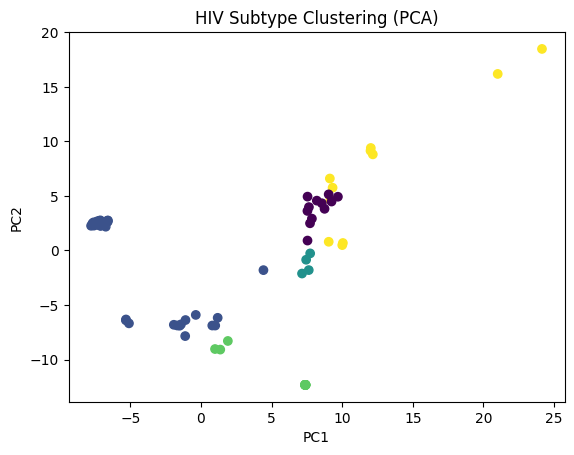

In [8]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
plt.title("HIV Subtype Clustering (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

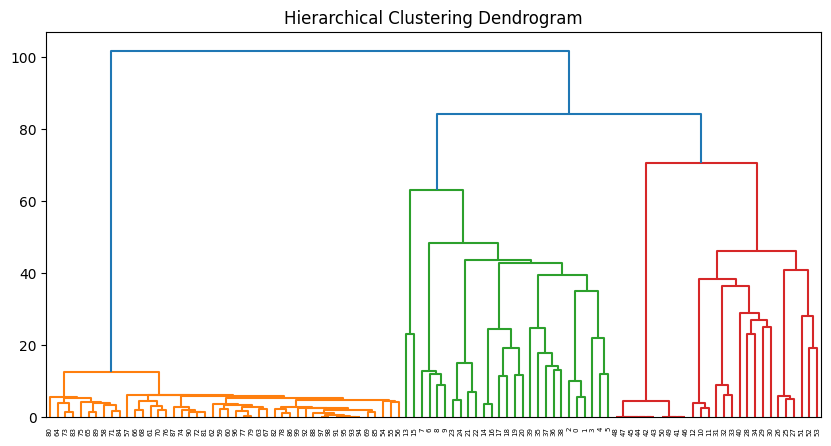

In [9]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.show()

In [10]:
import pandas as pd

df = pd.DataFrame(X)
df["Cluster"] = labels

df.to_csv("hiv_clusters.csv", index=False)

In [11]:
from Bio import Entrez, SeqIO
import pandas as pd
from tqdm import tqdm

Entrez.email = "your_email@example.com"

def fetch_hiv_with_metadata(max_records=200):
    handle = Entrez.esearch(
        db="nucleotide",
        term="HIV-1[Organism] AND complete genome",
        retmax=max_records
    )
    record = Entrez.read(handle)
    ids = record["IdList"]

    data = []

    for seq_id in tqdm(ids):
        try:
            handle = Entrez.efetch(
                db="nucleotide",
                id=seq_id,
                rettype="gb",
                retmode="text"
            )
            record = SeqIO.read(handle, "genbank")

            sequence = str(record.seq)

            # Extract subtype if available
            subtype = "Unknown"
            for feature in record.features:
                if feature.type == "source":
                    qualifiers = feature.qualifiers
                    if "note" in qualifiers:
                        subtype = qualifiers["note"][0]

            data.append({
                "id": seq_id,
                "sequence": sequence,
                "subtype": subtype
            })

        except:
            continue

    return pd.DataFrame(data)

df = fetch_hiv_with_metadata(150)
print(df.head())

100%|██████████| 150/150 [02:34<00:00,  1.03s/it]

           id                                           sequence  \
0  3101934176  ACGCAGGACTCGGCTTGCTGAAGTGCACTCGGCAAGAGGCGAGAGG...   
1  3101934166  ACTTGAAAGCGAAAGTAAAACCAGAGAAGATCTCTCGACGCAGGAC...   
2  3101934156  AAAGTAAAACCAGAGAAGATCTCTCGACGCAGGACTCGGCTTGCTG...   
3  3101934136  GCTGAAAGTGCACTCGGCAGGAGGCGAGAGGGGCGACTGGTGAGTA...   
4  3101934126  GCGCCCGAACAGGGACTTGAAAGCGAAAGTAAAACCAGAGAAGATC...   

                subtype  
0  subtype: CRF197_0108  
1  subtype: CRF197_0108  
2  subtype: CRF197_0108  
3  subtype: CRF177_0708  
4  subtype: CRF177_0708  


In [12]:
def clean_sequences(df, min_len=8000):
    df["sequence"] = df["sequence"].str.upper().str.replace("N", "", regex=False)
    df = df[df["sequence"].str.len() >= min_len]
    return df.reset_index(drop=True)

df = clean_sequences(df)
print("Clean dataset size:", df.shape)

Clean dataset size: (150, 3)


In [13]:
import itertools
import numpy as np

def generate_kmers(k=5):
    return [''.join(p) for p in itertools.product('ACGT', repeat=k)]

def compute_kmer_features(seq, kmers):
    k = len(kmers[0])
    counts = dict.fromkeys(kmers, 0)

    for i in range(len(seq) - k + 1):
        kmer = seq[i:i+k]
        if kmer in counts:
            counts[kmer] += 1

    total = sum(counts.values())
    freqs = [counts[k]/total if total > 0 else 0 for k in kmers]

    # Additional features
    gc = (seq.count("G") + seq.count("C")) / len(seq)
    length = len(seq)

    return freqs + [gc, length]

kmers = generate_kmers(k=4)

X = np.array([
    compute_kmer_features(seq, kmers)
    for seq in df["sequence"]
])

print("Feature matrix:", X.shape)

Feature matrix: (150, 258)


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [15]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
k_labels = kmeans.fit_predict(X_scaled)

In [16]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=5)
d_labels = dbscan.fit_predict(X_scaled)

In [17]:
from scipy.cluster.hierarchy import linkage, fcluster

Z = linkage(X_scaled, method='ward')
h_labels = fcluster(Z, t=5, criterion='maxclust')

In [18]:
from sklearn.metrics import silhouette_score

print("KMeans Score:", silhouette_score(X_scaled, k_labels))

# DBSCAN may fail if only one cluster
if len(set(d_labels)) > 1:
    print("DBSCAN Score:", silhouette_score(X_scaled, d_labels))

KMeans Score: 0.5805821968209405
DBSCAN Score: -0.08725650326614333


In [19]:
from sklearn.metrics import adjusted_rand_score

if "subtype" in df.columns:
    print("ARI (KMeans):", adjusted_rand_score(df["subtype"], k_labels))

ARI (KMeans): 0.7311305036926451


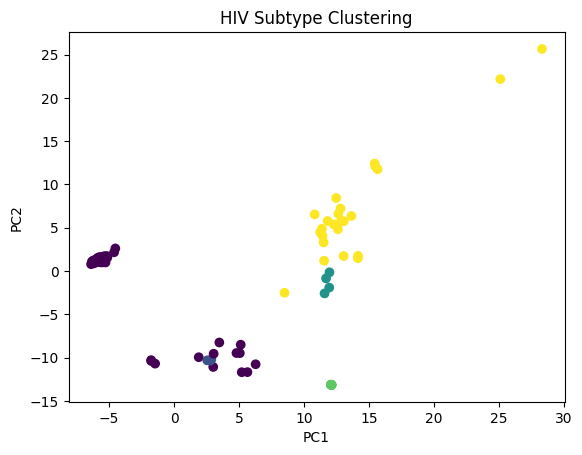

In [20]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=k_labels)
plt.title("HIV Subtype Clustering")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [21]:
df["KMeans_Cluster"] = k_labels
df["DBSCAN_Cluster"] = d_labels
df["Hierarchical_Cluster"] = h_labels

df.to_csv("advanced_hiv_clustering_results.csv", index=False)